In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import torch
import torchvision
import torchmetrics

from torch import optim
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import torchvision.datasets as datasets
import torchvision.transforms as transforms 


In [2]:
batch_size = 60
train_size = 50000
validation_size = 10000

train_validation_dataset = datasets.MNIST(root="dataset/", download=True, train=True, transform=transforms.ToTensor())

train_dataset, validation_dataset = torch.utils.data.random_split(train_validation_dataset, [train_size, validation_size])

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

validation_loader = DataLoader(dataset=validation_dataset, batch_size=batch_size, shuffle=False)

test_dataset = datasets.MNIST(root="dataset/", download=True, train=False, transform=transforms.ToTensor())

test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

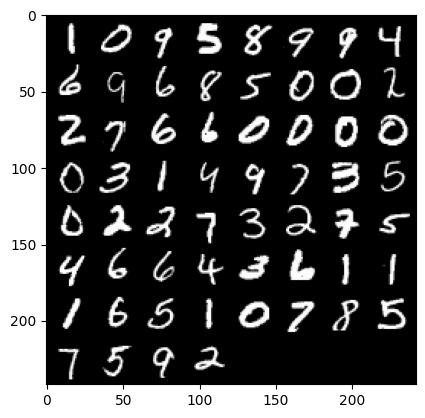

In [3]:
def imshow(img):
   npimg = img.numpy()
   plt.imshow(np.transpose(npimg, (1, 2, 0)))
   plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)
labels
imshow(torchvision.utils.make_grid(images))


In [ ]:
class CNN(nn.Module):
   def __init__(self, in_channels, num_classes):

       """
       Parameters:
           * in_channels: Number of channels in the input image (for grayscale images, 1)
           * num_classes: Number of classes to predict. MNIST, 10.
       """
       super(CNN, self).__init__()

       self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1)
       self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
       self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
       self.fc1 = nn.Linear(16 * 7 * 7, num_classes)
       self.dropout = nn.Dropout(0.5)

   def forward(self, x):
       """
       Define the forward pass of the neural network.

       Parameters:
           x: Input tensor.

       Returns:
           torch.Tensor
               The output tensor after passing through the network.
       """
       x = F.relu(self.conv1(x))  # Apply first convolution and ReLU activation
       x = self.pool(x)           # Apply max pooling
       x = F.relu(self.conv2(x))  # Apply second convolution and ReLU activation
       x = self.pool(x)           # Apply max pooling
       x = x.reshape(x.shape[0], -1)  # Flatten the tensor
       x = self.dropout(x)        # Apply dropout
       x = self.fc1(x)            # Apply fully connected layer
       return x